# 🕺🏻 2025년 K-LEAGUE 순위 예측 프로젝트 ⚽️

In [1892]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error

In [1893]:
# Window용 한글 폰트 오류 해결
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf
# plt.rc('font', family='NanumBarunGothic')

In [1894]:
# macOS용 한글 폰트 오류 해결
from matplotlib import rc
rc("font", family = "AppleGothic")

# 2020년부터 2025년까지 축구 기록 데이터(.csv) 불러오기

* "https://data.kleague.com/" 에서 "년도별 팀기록.csv" 데이터 수집
* "https://www.kleague.com/record/team.do" 에서 "승점.csv" 데이터 수집
* 2025년 데이터 수집 기준일: 2025년 4월 29일


#### Window용 (& Google Colab 사용) 데이터 읽기

In [1898]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1899]:
# 년도별 팀기록 데이터
# df2020 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2020년 팀기록.csv', encoding='cp949')
# df2021 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2021년 팀기록.csv', encoding='utf-8')
# df2022 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2022년 팀기록.csv', encoding='utf-8')
# df2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2023년 팀기록.csv', encoding='cp949')
# df2024 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2024년 팀기록.csv', encoding='utf-8')
# df2025 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2025년 팀기록.csv', encoding='utf-8')

In [1900]:
# 승점 (+승,무,패) & 경기수 데이터
# df_vic2020 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2020 승점.csv')
# df_vic2021 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2021 승점.csv')
# df_vic2022 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2022 승점.csv')
# df_vic2023 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2023 승점.csv')
# df_vic2024 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2024 승점.csv')
# df_vic2025 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/koreaIT/project/Data/2025 승점.csv')

#### macOS용 데이터 읽기

In [1902]:
# 년도별 팀기록 데이터
df2020 = pd.read_csv('./data/2020년 팀기록.csv', encoding="cp949")
df2021 = pd.read_csv('./data/2021년 팀기록.csv')
df2022 = pd.read_csv('./data/2022년 팀기록.csv')
df2023 = pd.read_csv('./data/2023년 팀기록.csv', encoding="cp949")
df2024 = pd.read_csv('./data/2024년 팀기록.csv')
df2025 = pd.read_csv('./data/2025년 팀기록.csv')

In [1903]:
# 승점 (+승,무,패) & 경기수 데이터
df_vic2020 = pd.read_csv('./data/2020 승점.csv')
df_vic2021 = pd.read_csv('./data/2021 승점.csv')
df_vic2022 = pd.read_csv('./data/2022 승점.csv')
df_vic2023 = pd.read_csv('./data/2023 승점.csv')
df_vic2024 = pd.read_csv('./data/2024 승점.csv')
df_vic2025 = pd.read_csv('./data/2025 승점.csv')

# 전처리 전, 데이터 확인

In [1905]:
print(df2020.shape, df2021.shape, df2022.shape, df2023.shape, df2024.shape, df2025.shape)

(12, 76) (12, 76) (12, 76) (12, 76) (12, 76) (12, 76)


In [1906]:
df2020.head()

,순위,년도,구단,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,...,클리어링,인터셉트,차단,획득,블락,볼미스,파울,피파울,경고,퇴장
0,7,2020,강원,36,24,325,110,98,117,170,...,398,350,946,1931,59,155,369,356,50,0
1,6,2020,광주,32,22,277,79,75,123,164,...,487,406,1204,2026,122,139,308,389,38,5
2,5,2020,대구,43,26,381,121,109,151,212,...,418,397,1125,2023,63,173,390,283,50,1
3,12,2020,부산,25,16,250,77,72,101,144,...,464,336,1054,1916,102,135,364,393,53,0
4,4,2020,상주,34,18,333,115,90,128,159,...,408,417,1038,2081,65,201,359,374,36,0


In [1907]:
df_vic2020.head()

,순위 ▾,구단,경기,승점,승,무,패,득점,실점,득실,최근 5경기
0,1,전북,27,60,19,3,5,46,21,25,승 승 승 패 승
1,2,울산,27,57,17,6,4,54,23,31,승 패 패 승 무
2,3,포항,27,50,15,5,7,56,35,21,승 패 승 승 승
3,4,상주,27,44,13,5,9,34,36,-2,패 승 승 패 패
4,5,대구,27,38,10,8,9,43,39,4,패 승 패 승 무


# 데이터 전처리 part 1 (concatenate로 각 데이터 합치기)

In [1909]:
# 2020년 ~ 2025년 팀기록 데이터 합치기
df = pd.concat([df2020, df2021, df2022, df2023, df2024, df2025])

In [1910]:
# 팀기록 데이터 확인
df.shape

(72, 76)

In [1911]:
# 팀기록 데이터 확인
df

,순위,년도,구단,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,...,클리어링,인터셉트,차단,획득,블락,볼미스,파울,피파울,경고,퇴장
0,7,2020,강원,36,24,325,110,98,117,170,...,398,350,946,1931,59,155,369,356,50,0
1,6,2020,광주,32,22,277,79,75,123,164,...,487,406,1204,2026,122,139,308,389,38,5
2,5,2020,대구,43,26,381,121,109,151,212,...,418,397,1125,2023,63,173,390,283,50,1
3,12,2020,부산,25,16,250,77,72,101,144,...,464,336,1054,1916,102,135,364,393,53,0
4,4,2020,상주,34,18,333,115,90,128,159,...,408,417,1038,2081,65,201,359,374,36,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,6,2025,안양,13,5,120,40,29,51,65,...,335,113,234,917,213,73,123,91,24,1
8,4,2025,울산,11,9,177,39,46,92,113,...,334,123,255,1141,238,61,142,146,20,0
9,2,2025,전북,15,10,104,38,25,41,69,...,266,100,225,804,172,54,133,114,19,1
10,10,2025,제주,10,8,111,34,22,55,66,...,298,110,239,908,210,62,137,104,16,1


In [1912]:
# 승점 데이터에는 연도 열을 추가한다
df_vic2020['년도'] = 2020
df_vic2021['년도'] = 2021
df_vic2022['년도'] = 2022
df_vic2023['년도'] = 2023
df_vic2024['년도'] = 2024
df_vic2025['년도'] = 2025

In [1913]:
# 2020년 ~ 2025년 승점 데이터 합치기
df_vic = pd.concat([df_vic2020, df_vic2021, df_vic2022, df_vic2023, df_vic2024, df_vic2025])

In [1914]:
# 승점 데이터 확인
df_vic.shape

(72, 12)

In [1915]:
# 승점 데이터 확인
df_vic

,순위 ▾,구단,경기,승점,승,무,패,득점,실점,득실,최근 5경기,년도
0,1,전북,27,60,19,3,5,46,21,25,승 승 승 패 승,2020
1,2,울산,27,57,17,6,4,54,23,31,승 패 패 승 무,2020
2,3,포항,27,50,15,5,7,56,35,21,승 패 승 승 승,2020
3,4,상주,27,44,13,5,9,34,36,-2,패 승 승 패 패,2020
4,5,대구,27,38,10,8,9,43,39,4,패 승 패 승 무,2020
...,...,...,...,...,...,...,...,...,...,...,...,...
7,8,서울,10,13,3,4,3,9,10,-1,패 패 무 무 승,2025
8,9,강원,10,13,4,1,5,7,9,-2,패 승 승 패 패,2025
9,10,제주,10,11,3,2,5,10,12,-2,패 승 무 패 승,2025
10,11,대구,10,7,2,1,7,10,16,-6,패 패 패 패 패,2025


# 데이터 전처리 part 2 (팀기록 데이터와 승점 데이터 합치기 -- merge)

In [1917]:
# 병합할 때 승점 데이터에서 필요한 열만 선택
df_vic_selected = df_vic[['구단', '년도', '경기','승점', '승', '무', '패']]

# 두 데이터프레임을 '구단'과 '년도' 열을 기준으로 병합
merged_df = pd.merge(df, df_vic_selected, on=['구단', '년도'], how='left')

# 결과 출력
merged_df

,순위,년도,구단,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,...,볼미스,파울,피파울,경고,퇴장,경기,승점,승,무,패
0,7,2020,강원,36,24,325,110,98,117,170,...,155,369,356,50,0,27,34,9,7,11
1,6,2020,광주,32,22,277,79,75,123,164,...,139,308,389,38,5,27,25,6,7,14
2,5,2020,대구,43,26,381,121,109,151,212,...,173,390,283,50,1,27,38,10,8,9
3,12,2020,부산,25,16,250,77,72,101,144,...,135,364,393,53,0,27,25,5,10,12
4,4,2020,상주,34,18,333,115,90,128,159,...,201,359,374,36,0,27,44,13,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6,2025,안양,13,5,120,40,29,51,65,...,73,123,91,24,1,11,15,5,0,6
68,4,2025,울산,11,9,177,39,46,92,113,...,61,142,146,20,0,12,17,5,2,5
69,2,2025,전북,15,10,104,38,25,41,69,...,54,133,114,19,1,10,18,5,3,2
70,10,2025,제주,10,8,111,34,22,55,66,...,62,137,104,16,1,10,11,3,2,5


In [1918]:
# 병합 데이터 확인; 결측치 없음
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   순위             72 non-null     int64  
 1   년도             72 non-null     int64  
 2   구단             72 non-null     object 
 3   득점             72 non-null     int64  
 4   도움             72 non-null     int64  
 5   슈팅             72 non-null     int64  
 6   유효 슈팅          72 non-null     int64  
 7   블락된슈팅          72 non-null     int64  
 8   벗어난슈팅          72 non-null     int64  
 9   PA내 슈팅         72 non-null     int64  
 10  PA외 슈팅         72 non-null     int64  
 11  프리킥 슈팅         72 non-null     int64  
 12  프리킥 유효슈팅       72 non-null     int64  
 13  프리킥 크로스 (시도)   72 non-null     int64  
 14  프리킥 크로스 (성공)   72 non-null     int64  
 15  프리킥 크로스 (성공%)  72 non-null     float64
 16  오프사이드          72 non-null     int64  
 17  코너킥            72 non-null     int64  
 18  스로인         

# 데이터 전처리 part 3 (새로운 열 추가: 승점, 승, 무, 패의 확률(%))

In [1920]:
# '경기' 열을 기준으로 승점, 승, 무, 패를 나눈 후, 새로운 열로 추가
merged_df['승점/경기'] = merged_df['승점'] / merged_df['경기']
merged_df['승/경기'] = merged_df['승'] / merged_df['경기']
merged_df['무/경기'] = merged_df['무'] / merged_df['경기']
merged_df['패/경기'] = merged_df['패'] / merged_df['경기']

# 결과 출력
merged_df

,순위,년도,구단,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,...,퇴장,경기,승점,승,무,패,승점/경기,승/경기,무/경기,패/경기
0,7,2020,강원,36,24,325,110,98,117,170,...,0,27,34,9,7,11,1.259259,0.333333,0.259259,0.407407
1,6,2020,광주,32,22,277,79,75,123,164,...,5,27,25,6,7,14,0.925926,0.222222,0.259259,0.518519
2,5,2020,대구,43,26,381,121,109,151,212,...,1,27,38,10,8,9,1.407407,0.370370,0.296296,0.333333
3,12,2020,부산,25,16,250,77,72,101,144,...,0,27,25,5,10,12,0.925926,0.185185,0.370370,0.444444
4,4,2020,상주,34,18,333,115,90,128,159,...,0,27,44,13,5,9,1.629630,0.481481,0.185185,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6,2025,안양,13,5,120,40,29,51,65,...,1,11,15,5,0,6,1.363636,0.454545,0.000000,0.545455
68,4,2025,울산,11,9,177,39,46,92,113,...,0,12,17,5,2,5,1.416667,0.416667,0.166667,0.416667
69,2,2025,전북,15,10,104,38,25,41,69,...,1,10,18,5,3,2,1.800000,0.500000,0.300000,0.200000
70,10,2025,제주,10,8,111,34,22,55,66,...,1,10,11,3,2,5,1.100000,0.300000,0.200000,0.500000


## 병합 데이터 이름을 'df'로 바꾸기

In [1922]:
df = merged_df

In [1923]:
# Replace commas in specific columns
for col in ['column1', 'column2', 'column3']:  # Replace with actual column names
  if col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '')
    # Convert back to numeric if necessary
    try:
      df[col] = pd.to_numeric(df[col])
    except ValueError:
      print(f"Column '{col}' could not be converted back to numeric after comma removal.")

# Alternatively, replace commas in all string columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '')
        try:
            df[col] = pd.to_numeric(df[col])
        except ValueError:
            print(f"Column '{col}' could not be converted back to numeric after comma removal.")

Column '구단' could not be converted back to numeric after comma removal.


In [1924]:
# 콤마 제거된 데이터 확인
df.head()

,순위,년도,구단,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,...,퇴장,경기,승점,승,무,패,승점/경기,승/경기,무/경기,패/경기
0,7,2020,강원,36,24,325,110,98,117,170,...,0,27,34,9,7,11,1.259259,0.333333,0.259259,0.407407
1,6,2020,광주,32,22,277,79,75,123,164,...,5,27,25,6,7,14,0.925926,0.222222,0.259259,0.518519
2,5,2020,대구,43,26,381,121,109,151,212,...,1,27,38,10,8,9,1.407407,0.370370,0.296296,0.333333
3,12,2020,부산,25,16,250,77,72,101,144,...,0,27,25,5,10,12,0.925926,0.185185,0.370370,0.444444
4,4,2020,상주,34,18,333,115,90,128,159,...,0,27,44,13,5,9,1.629630,0.481481,0.185185,0.333333


In [1925]:
# 콤마 제거된 데이터 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   순위             72 non-null     int64  
 1   년도             72 non-null     int64  
 2   구단             72 non-null     object 
 3   득점             72 non-null     int64  
 4   도움             72 non-null     int64  
 5   슈팅             72 non-null     int64  
 6   유효 슈팅          72 non-null     int64  
 7   블락된슈팅          72 non-null     int64  
 8   벗어난슈팅          72 non-null     int64  
 9   PA내 슈팅         72 non-null     int64  
 10  PA외 슈팅         72 non-null     int64  
 11  프리킥 슈팅         72 non-null     int64  
 12  프리킥 유효슈팅       72 non-null     int64  
 13  프리킥 크로스 (시도)   72 non-null     int64  
 14  프리킥 크로스 (성공)   72 non-null     int64  
 15  프리킥 크로스 (성공%)  72 non-null     float64
 16  오프사이드          72 non-null     int64  
 17  코너킥            72 non-null     int64  
 18  스로인         

In [1926]:
df.describe()

,순위,년도,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,PA외 슈팅,...,퇴장,경기,승점,승,무,패,승점/경기,승/경기,무/경기,패/경기
count,72.000000,72.00000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,...,72.000000,72.000000,72.00000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,6.500000,2022.50000,39.986111,25.250000,363.722222,125.888889,79.833333,158.000000,208.791667,154.930556,...,1.319444,31.555556,43.00000,11.444444,8.666667,11.444444,1.365579,0.366084,0.267327,0.366589
std,3.476278,1.71981,16.191193,11.071789,125.568367,47.084149,28.799941,56.209618,74.741986,55.992536,...,1.254023,10.381306,17.75181,5.275211,4.097406,5.159127,0.352788,0.125565,0.087082,0.122510
min,1.000000,2020.00000,7.000000,5.000000,75.000000,27.000000,15.000000,28.000000,50.000000,20.000000,...,0.000000,10.000000,7.00000,1.000000,0.000000,2.000000,0.700000,0.100000,0.000000,0.148148
25%,3.750000,2021.00000,31.500000,17.750000,321.000000,107.750000,72.000000,121.250000,162.750000,139.500000,...,0.000000,27.000000,30.75000,7.750000,5.750000,7.000000,1.125000,0.282895,0.219298,0.289474
50%,6.500000,2022.50000,43.000000,26.000000,413.500000,138.000000,84.000000,181.000000,234.500000,169.000000,...,1.000000,38.000000,46.00000,12.000000,9.000000,12.000000,1.321053,0.355263,0.263158,0.381579
75%,9.250000,2024.00000,52.250000,32.250000,451.000000,160.250000,98.000000,197.750000,260.000000,186.000000,...,2.000000,38.000000,54.25000,15.000000,11.000000,15.250000,1.559211,0.421053,0.315789,0.445175
max,12.000000,2025.00000,71.000000,45.000000,520.000000,197.000000,134.000000,229.000000,303.000000,239.000000,...,5.000000,38.000000,76.00000,23.000000,16.000000,22.000000,2.222222,0.703704,0.421053,0.700000


# 데이터 전처리 part 4 (성공% 관련 열 이상치, 순위 불균형 확인하기)

In [1928]:
df.columns

Index(['순위', '년도', '구단', '득점', '도움', '슈팅', '유효 슈팅', '블락된슈팅', '벗어난슈팅', 'PA내 슈팅',
       'PA외 슈팅', '프리킥 슈팅', '프리킥 유효슈팅', '프리킥 크로스 (시도)', '프리킥 크로스 (성공)',
       '프리킥 크로스 (성공%)', '오프사이드', '코너킥', '스로인', '드리블 (시도)', '드리블 (성공)',
       '드리블 (성공%)', '패스 (시도)', '패스 (성공)', '패스 (성공%)', '키패스', '전방패스 (시도)',
       '전방패스 (성공)', '전방패스 (성공%)', '후방패스 (시도)', '후방패스 (성공)', '후방패스 (성공%)',
       '횡패스 (시도)', '횡패스 (성공)', '횡패스 (성공%)', '공격진영 패스 (시도)', '공격진영 패스 (성공)',
       '공격진영 패스 (성공%)', '수비진영 패스 (시도)', '수비진영 패스 (성공)', '수비진영 패스 (성공%)',
       '중앙진영 패스 (시도)', '중앙진영 패스 (성공)', '중앙진영 패스 (성공%)', '롱패스 (시도)', '롱패스 (성공)',
       '롱패스 (성공%)', '중거리패스 (시도)', '중거리패스 (성공)', '중거리패스 (성공%)', '단거리패스 (시도)',
       '단거리패스 (성공)', '단거리패스 (성공%)', '크로스 (시도)', '크로스 (성공)', '크로스 (성공%)', '탈압박',
       '경합 지상 (시도)', '경합 지상 (성공)', '경합 지상 (성공%)', '경합 공중 (시도)', '경합 공중 (성공)',
       '경합 공중 (성공%)', '태클 (시도)', '태클 (성공)', '태클 (성공%)', '클리어링', '인터셉트', '차단',
       '획득', '블락', '볼미스', '파울', '피파울', '경고', '퇴장', '경기', '승점', '승', '무', '패',
       '승점

In [1929]:
percent_cols = df[['프리킥 크로스 (성공%)','드리블 (성공%)','패스 (성공%)','전방패스 (성공%)','후방패스 (성공%)','횡패스 (성공%)',
                   '공격진영 패스 (성공%)','수비진영 패스 (성공%)','중앙진영 패스 (성공%)','롱패스 (성공%)','중거리패스 (성공%)',
                   '단거리패스 (성공%)','크로스 (성공%)','경합 지상 (성공%)','경합 공중 (성공%)','태클 (성공%)']]

In [1930]:
percent_cols.shape

(72, 16)

In [1931]:
percent_cols.describe()

,프리킥 크로스 (성공%),드리블 (성공%),패스 (성공%),전방패스 (성공%),후방패스 (성공%),횡패스 (성공%),공격진영 패스 (성공%),수비진영 패스 (성공%),중앙진영 패스 (성공%),롱패스 (성공%),중거리패스 (성공%),단거리패스 (성공%),크로스 (성공%),경합 지상 (성공%),경합 공중 (성공%),태클 (성공%)
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,600.681944,28.622222,82.477778,68.420833,96.209722,90.650000,77.238889,79.138889,86.150000,56.418056,86.465278,86.409722,21.531944,49.955556,50.025000,38.684722
std,301.102375,5.398545,3.566243,4.306233,0.710120,3.738117,6.471009,4.782084,2.687949,5.807434,3.456048,2.620835,2.312661,2.284170,2.223039,9.624143
min,33.300000,17.200000,72.400000,59.000000,93.900000,79.700000,63.900000,68.000000,78.800000,46.800000,75.200000,78.700000,15.500000,43.600000,44.900000,26.500000
25%,364.600000,26.200000,80.375000,64.800000,95.900000,87.175000,71.375000,76.325000,84.400000,52.550000,84.350000,84.775000,20.000000,48.850000,48.425000,31.750000
50%,600.850000,28.800000,82.650000,68.150000,96.300000,92.300000,80.000000,79.300000,86.100000,55.950000,86.800000,86.900000,21.500000,50.200000,50.250000,33.900000
75%,852.100000,32.850000,84.925000,71.700000,96.600000,93.500000,82.700000,82.750000,88.150000,59.300000,89.025000,88.225000,23.000000,51.250000,51.350000,47.800000
max,1291.700000,38.100000,88.700000,77.600000,97.800000,95.200000,86.300000,88.000000,91.100000,74.600000,92.500000,90.700000,26.900000,57.300000,55.600000,59.800000


* comments:
    * 프리킥 크로스가 성공률이 많이 높음; 이상치가 있을 확률이 높아보인다.
    * 변수들 간의 상관관계를 파악할 때, box plot을 사용해야할 것 같다.

In [1933]:
# 순위 열의 불균형 확인
df['순위'].sort_values().value_counts()

# 각 순위가 총 6개씩 나옴으로써 이상 없음

순위
1     6
2     6
3     6
4     6
5     6
6     6
7     6
8     6
9     6
10    6
11    6
12    6
Name: count, dtype: int64

# 변수들 간 상관관계 분석

In [1935]:
# object값인 '구단'을 제외하고 상관관계
corr = df.drop(columns=['구단']).corr()
corr = corr.abs()
corr = corr.unstack().sort_values(ascending=False).drop_duplicates()
corr.head(10)

순위            순위              1.000000
후방패스 (성공)     후방패스 (시도)       0.999857
경합 지상 (성공)    경합 지상 (시도)      0.999189
중앙진영 패스 (시도)  중앙진영 패스 (성공)    0.997043
단거리패스 (시도)    단거리패스 (성공)      0.996845
패스 (성공)       중앙진영 패스 (성공)    0.996472
패스 (시도)       중앙진영 패스 (시도)    0.995895
횡패스 (시도)      횡패스 (성공)        0.995248
중거리패스 (시도)    중거리패스 (성공)      0.995006
경합 공중 (시도)    경합 공중 (성공)      0.993161
dtype: float64

* comments:
    * 패스 간 상관관계가 높다.
    * 랜덤 포레스트는 상관성에 영향을 받지 않지만 고려해봐야할 부분

# 순위와의 상관관계 분석 part 1 (컬럼 값을 %로 변환하기 전)

## corr()로 알아보기

In [1939]:
# 01. corr로 알아보기
corr = df.drop(columns=['년도','구단']).corr()

# 우승팀과의 상관계수만 추출
corr_target = corr['순위'].drop('순위') # 당연히 우승팀이 상관이 가장 높게 나와서 제외시킴 + 당연히 순위가 높을수록 승점이 높음

# 우승팀과 상관 높은 순으로 정렬
corr_target = corr_target.abs().sort_values(ascending=False)

# Top 10만 보기
top10_features = corr_target.head(10)

print(top10_features)

승점/경기            0.918372
승/경기             0.894248
패/경기             0.811508
승                0.649767
패                0.582713
승점               0.558038
도움               0.410950
득점               0.389241
중앙진영 패스 (성공%)    0.328898
전방패스 (성공%)       0.320225
Name: 순위, dtype: float64


## RandomForestClassifier, feature_importances_로 알아보기

In [1941]:
x = df.drop(columns=['구단', '년도','순위'])
y_champion = df['순위']

# 모델 만들기
model = RandomForestClassifier(random_state = 22)

# 학습하기
model.fit(x, y_champion)

# 변수 중요도 뽑기
importances = model.feature_importances_

# 중요도랑 컬럼 이름 연결
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
})

# 중요도 높은 순으로 정렬
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 결과 확인
feature_importance.head(20)

,Feature,Importance
78,승점/경기,0.070625
79,승/경기,0.052750
81,패/경기,0.038595
75,승,0.027826
77,패,0.025962
18,드리블 (성공%),0.021766
59,경합 공중 (성공%),0.020361
43,롱패스 (성공%),0.019910
4,블락된슈팅,0.019289
74,승점,0.019078


* comments: 
    * 중요도를 나눠 갖은 느낌이다.
    * 중요도 해석은 상관된 변수끼리 왜곡될 수 있음
* note:
    * corr(): 변수와 목표값 사이의 선형 관계, 변수 간 독립적으로 봄, 스케일에 민감, 탐색적 분석, 기초적인 관계 파악
    * feature_importance: 모델 예측에 실제 기여, 비선형, 상호작용도 반영, 여러 변수의 조합 효과를 고려, 스케일에 영향을 받지 않음

# 데이터 전처리 part 5 (성공% 구한 후, 열 추가)

In [1944]:
# 설명: 특정 슈팅의 성공%를 구하는 함수
# col1 = '블락된슈팅' ; string object
# col2 = '슈팅'; string object

def percentage(df, col1, col2):
    # Check if the columns exist before performing calculations
    if col1 in df.columns and col2 in df.columns:
        df[col1 + ' (성공%)'] = df[col1] / df[col2].replace(0, np.nan)  # Replace 0 with NaN to avoid division by zero errors
    else:
        print('Either' + col1 + 'or' + col2 +  'column is not found in the DataFrame.')

In [1945]:
percentage(df, '유효 슈팅', '슈팅')
percentage(df, '블락된슈팅', '슈팅')
percentage(df, '벗어난슈팅', '슈팅')
percentage(df, 'PA내 슈팅', '슈팅')
percentage(df, 'PA외 슈팅', '슈팅')
percentage(df, '프리킥 슈팅', '경기')
percentage(df, '프리킥 유효슈팅', '경기')

In [1946]:
# 새로운 열이 추가된 데이터 확인
df.head()

,순위,년도,구단,득점,도움,슈팅,유효 슈팅,블락된슈팅,벗어난슈팅,PA내 슈팅,...,승/경기,무/경기,패/경기,유효 슈팅 (성공%),블락된슈팅 (성공%),벗어난슈팅 (성공%),PA내 슈팅 (성공%),PA외 슈팅 (성공%),프리킥 슈팅 (성공%),프리킥 유효슈팅 (성공%)
0,7,2020,강원,36,24,325,110,98,117,170,...,0.333333,0.259259,0.407407,0.338462,0.301538,0.360000,0.523077,0.476923,0.666667,0.185185
1,6,2020,광주,32,22,277,79,75,123,164,...,0.222222,0.259259,0.518519,0.285199,0.270758,0.444043,0.592058,0.407942,0.555556,0.148148
2,5,2020,대구,43,26,381,121,109,151,212,...,0.370370,0.296296,0.333333,0.317585,0.286089,0.396325,0.556430,0.443570,0.740741,0.148148
3,12,2020,부산,25,16,250,77,72,101,144,...,0.185185,0.370370,0.444444,0.308000,0.288000,0.404000,0.576000,0.424000,0.666667,0.148148
4,4,2020,상주,34,18,333,115,90,128,159,...,0.481481,0.185185,0.333333,0.345345,0.270270,0.384384,0.477477,0.522523,0.888889,0.222222


In [1947]:
# 성공% 열 확인
df[['승점/경기','승/경기','무/경기','패/경기','유효 슈팅 (성공%)','블락된슈팅 (성공%)','벗어난슈팅 (성공%)','PA내 슈팅 (성공%)',
    'PA외 슈팅 (성공%)','프리킥 크로스 (성공%)','드리블 (성공%)','패스 (성공%)','전방패스 (성공%)','후방패스 (성공%)','횡패스 (성공%)',
    '수비진영 패스 (성공%)','중앙진영 패스 (성공%)','롱패스 (성공%)','중거리패스 (성공%)','단거리패스 (성공%)','크로스 (성공%)',
    '경합 지상 (성공%)','경합 공중 (성공%)','태클 (성공%)','프리킥 슈팅 (성공%)', '프리킥 유효슈팅 (성공%)']]

,승점/경기,승/경기,무/경기,패/경기,유효 슈팅 (성공%),블락된슈팅 (성공%),벗어난슈팅 (성공%),PA내 슈팅 (성공%),PA외 슈팅 (성공%),프리킥 크로스 (성공%),...,중앙진영 패스 (성공%),롱패스 (성공%),중거리패스 (성공%),단거리패스 (성공%),크로스 (성공%),경합 지상 (성공%),경합 공중 (성공%),태클 (성공%),프리킥 슈팅 (성공%),프리킥 유효슈팅 (성공%)
0,1.259259,0.333333,0.259259,0.407407,0.338462,0.301538,0.360000,0.523077,0.476923,278.3,...,89.8,57.8,87.6,87.7,17.5,47.7,48.1,40.9,0.666667,0.185185
1,0.925926,0.222222,0.259259,0.518519,0.285199,0.270758,0.444043,0.592058,0.407942,556.0,...,78.8,50.8,75.2,79.5,20.5,51.0,51.3,59.8,0.555556,0.148148
2,1.407407,0.370370,0.296296,0.333333,0.317585,0.286089,0.396325,0.556430,0.443570,700.0,...,86.3,58.0,82.2,83.9,22.1,52.4,54.0,43.4,0.740741,0.148148
3,0.925926,0.185185,0.370370,0.444444,0.308000,0.288000,0.404000,0.576000,0.424000,491.7,...,85.3,59.0,83.6,84.7,18.8,43.6,46.4,50.2,0.666667,0.148148
4,1.629630,0.481481,0.185185,0.333333,0.345345,0.270270,0.384384,0.477477,0.522523,273.3,...,87.8,52.9,86.1,87.0,20.6,46.3,48.9,47.8,0.888889,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,1.363636,0.454545,0.000000,0.545455,0.333333,0.241667,0.425000,0.541667,0.458333,200.0,...,83.2,51.9,83.6,85.7,19.2,52.9,46.6,32.4,0.636364,0.000000
68,1.416667,0.416667,0.166667,0.416667,0.220339,0.259887,0.519774,0.638418,0.361582,216.7,...,87.0,56.3,87.4,88.5,20.0,49.4,50.9,26.5,0.333333,0.083333
69,1.800000,0.500000,0.300000,0.200000,0.365385,0.240385,0.394231,0.663462,0.336538,333.3,...,85.5,54.5,86.9,86.5,24.7,50.0,50.3,34.8,0.300000,0.000000
70,1.100000,0.300000,0.200000,0.500000,0.306306,0.198198,0.495495,0.594595,0.405405,100.0,...,83.3,47.8,82.7,86.6,26.7,51.8,47.9,31.0,0.200000,0.100000


In [1948]:
# 설명: df['득점', '도움', '키패스', '클리어링', '인터셉트', '오프사이드', '스로인', '탈압박', '코너킥', '차단', '획득', ...
# ... '블락', '볼미스', '파울', '피파울', '경고', '퇴장']를 df['경기']로 나눠서 대체하는 코드

cols_to_normalize = ['슈팅','득점', '도움', '키패스', '클리어링', '인터셉트', '오프사이드', '스로인', '탈압박', 
                     '코너킥', '차단', '획득', '블락', '볼미스', '파울', '피파울', '경고', '퇴장']

for col in cols_to_normalize:
  if col in df.columns:
    df[col] = df[col] / df['경기']
  else:
    print(f"Column '{col}' not found in DataFrame.")

In [1949]:
# 데이터 확인
df[['슈팅','득점', '도움', '키패스', '클리어링', '인터셉트', '오프사이드', '스로인', '탈압박', 
    '코너킥', '차단', '획득', '블락', '볼미스', '파울', '피파울', '경고', '퇴장']]

,슈팅,득점,도움,키패스,클리어링,인터셉트,오프사이드,스로인,탈압박,코너킥,차단,획득,블락,볼미스,파울,피파울,경고,퇴장
0,12.037037,1.333333,0.888889,7.481481,14.740741,12.962963,0.851852,18.666667,0.518519,5.851852,35.037037,71.518519,2.185185,5.740741,13.666667,13.185185,1.851852,0.000000
1,10.259259,1.185185,0.814815,6.148148,18.037037,15.037037,1.814815,19.555556,0.592593,3.666667,44.592593,75.037037,4.518519,5.148148,11.407407,14.407407,1.407407,0.185185
2,14.111111,1.592593,0.962963,8.444444,15.481481,14.703704,1.555556,19.037037,0.555556,4.666667,41.666667,74.925926,2.333333,6.407407,14.444444,10.481481,1.851852,0.037037
3,9.259259,0.925926,0.592593,5.888889,17.185185,12.444444,1.222222,18.296296,0.333333,4.407407,39.037037,70.962963,3.777778,5.000000,13.481481,14.555556,1.962963,0.000000
4,12.333333,1.259259,0.666667,6.370370,15.111111,15.444444,1.333333,20.148148,0.851852,4.370370,38.444444,77.074074,2.407407,7.444444,13.296296,13.851852,1.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,10.909091,1.181818,0.454545,5.363636,30.454545,10.272727,1.636364,19.090909,0.000000,3.636364,21.272727,83.363636,19.363636,6.636364,11.181818,8.272727,2.181818,0.090909
68,14.750000,0.916667,0.750000,7.916667,27.833333,10.250000,1.916667,19.916667,0.000000,5.666667,21.250000,95.083333,19.833333,5.083333,11.833333,12.166667,1.666667,0.000000
69,10.400000,1.500000,1.000000,6.200000,26.600000,10.000000,1.200000,20.100000,0.000000,5.100000,22.500000,80.400000,17.200000,5.400000,13.300000,11.400000,1.900000,0.100000
70,11.100000,1.000000,0.800000,7.100000,29.800000,11.000000,1.000000,22.900000,0.000000,3.600000,23.900000,90.800000,21.000000,6.200000,13.700000,10.400000,1.600000,0.100000


In [1950]:
# 총 컬럼 확인
df.columns

Index(['순위', '년도', '구단', '득점', '도움', '슈팅', '유효 슈팅', '블락된슈팅', '벗어난슈팅', 'PA내 슈팅',
       'PA외 슈팅', '프리킥 슈팅', '프리킥 유효슈팅', '프리킥 크로스 (시도)', '프리킥 크로스 (성공)',
       '프리킥 크로스 (성공%)', '오프사이드', '코너킥', '스로인', '드리블 (시도)', '드리블 (성공)',
       '드리블 (성공%)', '패스 (시도)', '패스 (성공)', '패스 (성공%)', '키패스', '전방패스 (시도)',
       '전방패스 (성공)', '전방패스 (성공%)', '후방패스 (시도)', '후방패스 (성공)', '후방패스 (성공%)',
       '횡패스 (시도)', '횡패스 (성공)', '횡패스 (성공%)', '공격진영 패스 (시도)', '공격진영 패스 (성공)',
       '공격진영 패스 (성공%)', '수비진영 패스 (시도)', '수비진영 패스 (성공)', '수비진영 패스 (성공%)',
       '중앙진영 패스 (시도)', '중앙진영 패스 (성공)', '중앙진영 패스 (성공%)', '롱패스 (시도)', '롱패스 (성공)',
       '롱패스 (성공%)', '중거리패스 (시도)', '중거리패스 (성공)', '중거리패스 (성공%)', '단거리패스 (시도)',
       '단거리패스 (성공)', '단거리패스 (성공%)', '크로스 (시도)', '크로스 (성공)', '크로스 (성공%)', '탈압박',
       '경합 지상 (시도)', '경합 지상 (성공)', '경합 지상 (성공%)', '경합 공중 (시도)', '경합 공중 (성공)',
       '경합 공중 (성공%)', '태클 (시도)', '태클 (성공)', '태클 (성공%)', '클리어링', '인터셉트', '차단',
       '획득', '블락', '볼미스', '파울', '피파울', '경고', '퇴장', '경기', '승점', '승', '무', '패',
       '승점

# 순위와의 상관관계 분석 part 2 (컬럼을 경기수로 나눈 전처리 과정을 마친 후)

### corr()로 알아보기

In [1953]:
corr = df.drop(columns=['득점', '도움','년도','구단', '승점', '경기', '승', '무', '패', '승점/경기', '승/경기', '무/경기', '패/경기']).corr()

# 우승팀과의 상관계수만 추출
corr_target = corr['순위'].drop('순위') # 당연히 우승팀이 상관이 가장 높게 나와서 제외시킴 + 당연히 순위가 높을수록 승점이 높음

# 우승팀과 상관 높은 순으로 정렬
corr_target = corr_target.abs().sort_values(ascending=False)

# Top 10만 보기
top10_features = corr_target.head(10)

top10_features

유효 슈팅 (성공%)      0.472981
벗어난슈팅 (성공%)      0.385219
PA외 슈팅 (성공%)     0.377560
PA내 슈팅 (성공%)     0.377560
키패스              0.362646
중앙진영 패스 (성공%)    0.328898
코너킥              0.320469
전방패스 (성공%)       0.320225
슈팅               0.317925
공격진영 패스 (성공)     0.262043
Name: 순위, dtype: float64

### RandomForestClassifier, feature_importances_로 알아보기

In [1955]:
x = df.drop(columns=['득점', '도움','구단', '년도','순위', '승점', '경기', '승', '무', '패', '승점/경기', '승/경기', '무/경기', '패/경기'])
y_champion = df['순위']

# 모델 만들기
model = RandomForestClassifier(random_state = 22)

# 학습하기
model.fit(x, y_champion)

# 변수 중요도 뽑기
importances = model.feature_importances_

# 중요도랑 컬럼 이름 연결
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
})

# 중요도 높은 순으로 정렬
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 결과 확인
feature_importance.head(20)

,Feature,Importance
71,유효 슈팅 (성공%),0.027747
35,수비진영 패스 (성공%),0.025251
75,PA외 슈팅 (성공%),0.024868
20,키패스,0.024331
12,코너킥,0.024150
74,PA내 슈팅 (성공%),0.023128
73,벗어난슈팅 (성공%),0.022166
69,경고,0.021694
0,슈팅,0.021414
26,후방패스 (성공%),0.021125


* comment:
    * RandomForestClassifier 모델로 중요도 나눈 것보다 corr 함수 사용한게 더 비율이 높다

# 모델 전 필요한 컬럼만 추출

In [1958]:
data_df = df[['경기','슈팅','구단','순위','년도','프리킥 슈팅','프리킥 유효슈팅','유효 슈팅 (성공%)','블락된슈팅 (성공%)',
              '벗어난슈팅 (성공%)','PA내 슈팅 (성공%)','PA외 슈팅 (성공%)','프리킥 크로스 (성공%)','드리블 (성공%)',
              '패스 (성공%)','전방패스 (성공%)','후방패스 (성공%)','횡패스 (성공%)','공격진영 패스 (성공%)','수비진영 패스 (성공%)',
              '중앙진영 패스 (성공%)','롱패스 (성공%)','중거리패스 (성공%)','단거리패스 (성공%)','크로스 (성공%)','경합 지상 (성공%)',
              '경합 공중 (성공%)','태클 (성공%)','승점/경기','승/경기','무/경기','패/경기', '승점','득점', '도움', '키패스', '클리어링',
              '인터셉트', '오프사이드', '스로인', '탈압박', '코너킥', '차단', '획득', '블락', '볼미스', '파울', '피파울', '경고', '퇴장' ]]

In [1959]:
# 데이터 확인
data_df

,경기,슈팅,구단,순위,년도,프리킥 슈팅,프리킥 유효슈팅,유효 슈팅 (성공%),블락된슈팅 (성공%),벗어난슈팅 (성공%),...,탈압박,코너킥,차단,획득,블락,볼미스,파울,피파울,경고,퇴장
0,27,12.037037,강원,7,2020,18,5,0.338462,0.301538,0.360000,...,0.518519,5.851852,35.037037,71.518519,2.185185,5.740741,13.666667,13.185185,1.851852,0.000000
1,27,10.259259,광주,6,2020,15,4,0.285199,0.270758,0.444043,...,0.592593,3.666667,44.592593,75.037037,4.518519,5.148148,11.407407,14.407407,1.407407,0.185185
2,27,14.111111,대구,5,2020,20,4,0.317585,0.286089,0.396325,...,0.555556,4.666667,41.666667,74.925926,2.333333,6.407407,14.444444,10.481481,1.851852,0.037037
3,27,9.259259,부산,12,2020,18,4,0.308000,0.288000,0.404000,...,0.333333,4.407407,39.037037,70.962963,3.777778,5.000000,13.481481,14.555556,1.962963,0.000000
4,27,12.333333,상주,4,2020,24,6,0.345345,0.270270,0.384384,...,0.851852,4.370370,38.444444,77.074074,2.407407,7.444444,13.296296,13.851852,1.333333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,11,10.909091,안양,6,2025,7,0,0.333333,0.241667,0.425000,...,0.000000,3.636364,21.272727,83.363636,19.363636,6.636364,11.181818,8.272727,2.181818,0.090909
68,12,14.750000,울산,4,2025,4,1,0.220339,0.259887,0.519774,...,0.000000,5.666667,21.250000,95.083333,19.833333,5.083333,11.833333,12.166667,1.666667,0.000000
69,10,10.400000,전북,2,2025,3,0,0.365385,0.240385,0.394231,...,0.000000,5.100000,22.500000,80.400000,17.200000,5.400000,13.300000,11.400000,1.900000,0.100000
70,10,11.100000,제주,10,2025,2,1,0.306306,0.198198,0.495495,...,0.000000,3.600000,23.900000,90.800000,21.000000,6.200000,13.700000,10.400000,1.600000,0.100000


# 구단에 One-Hot Encoder 생성 및 적용

In [1961]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(data_df[['구단']])

# 인코딩된 컬럼 이름 생성
encoded_cols = encoder.get_feature_names_out(['구단'])

# NumPy 배열 → DataFrame 변환
encoded_df = pd.DataFrame(encoded, columns=encoded_cols)

# 인덱스 맞추기 (중요)
encoded_df.index = data_df.index

# 원본과 인코딩 결과 합치기
data_df = pd.concat([data_df, encoded_df], axis=1)

data_df

,경기,슈팅,구단,순위,년도,프리킥 슈팅,프리킥 유효슈팅,유효 슈팅 (성공%),블락된슈팅 (성공%),벗어난슈팅 (성공%),...,구단_서울,구단_성남,구단_수원,구단_수원FC,구단_안양,구단_울산,구단_인천,구단_전북,구단_제주,구단_포항
0,27,12.037037,강원,7,2020,18,5,0.338462,0.301538,0.360000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,27,10.259259,광주,6,2020,15,4,0.285199,0.270758,0.444043,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,27,14.111111,대구,5,2020,20,4,0.317585,0.286089,0.396325,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,27,9.259259,부산,12,2020,18,4,0.308000,0.288000,0.404000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,27,12.333333,상주,4,2020,24,6,0.345345,0.270270,0.384384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,11,10.909091,안양,6,2025,7,0,0.333333,0.241667,0.425000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,12,14.750000,울산,4,2025,4,1,0.220339,0.259887,0.519774,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
69,10,10.400000,전북,2,2025,3,0,0.365385,0.240385,0.394231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
70,10,11.100000,제주,10,2025,2,1,0.306306,0.198198,0.495495,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# 순위와의 상관관계 시각화로 파악하기

## PAIR PLOT
* 순위를 기준으로 순위와 상관관계가 높았던 상위 10개의 변수들 간의 상관관계를 파악

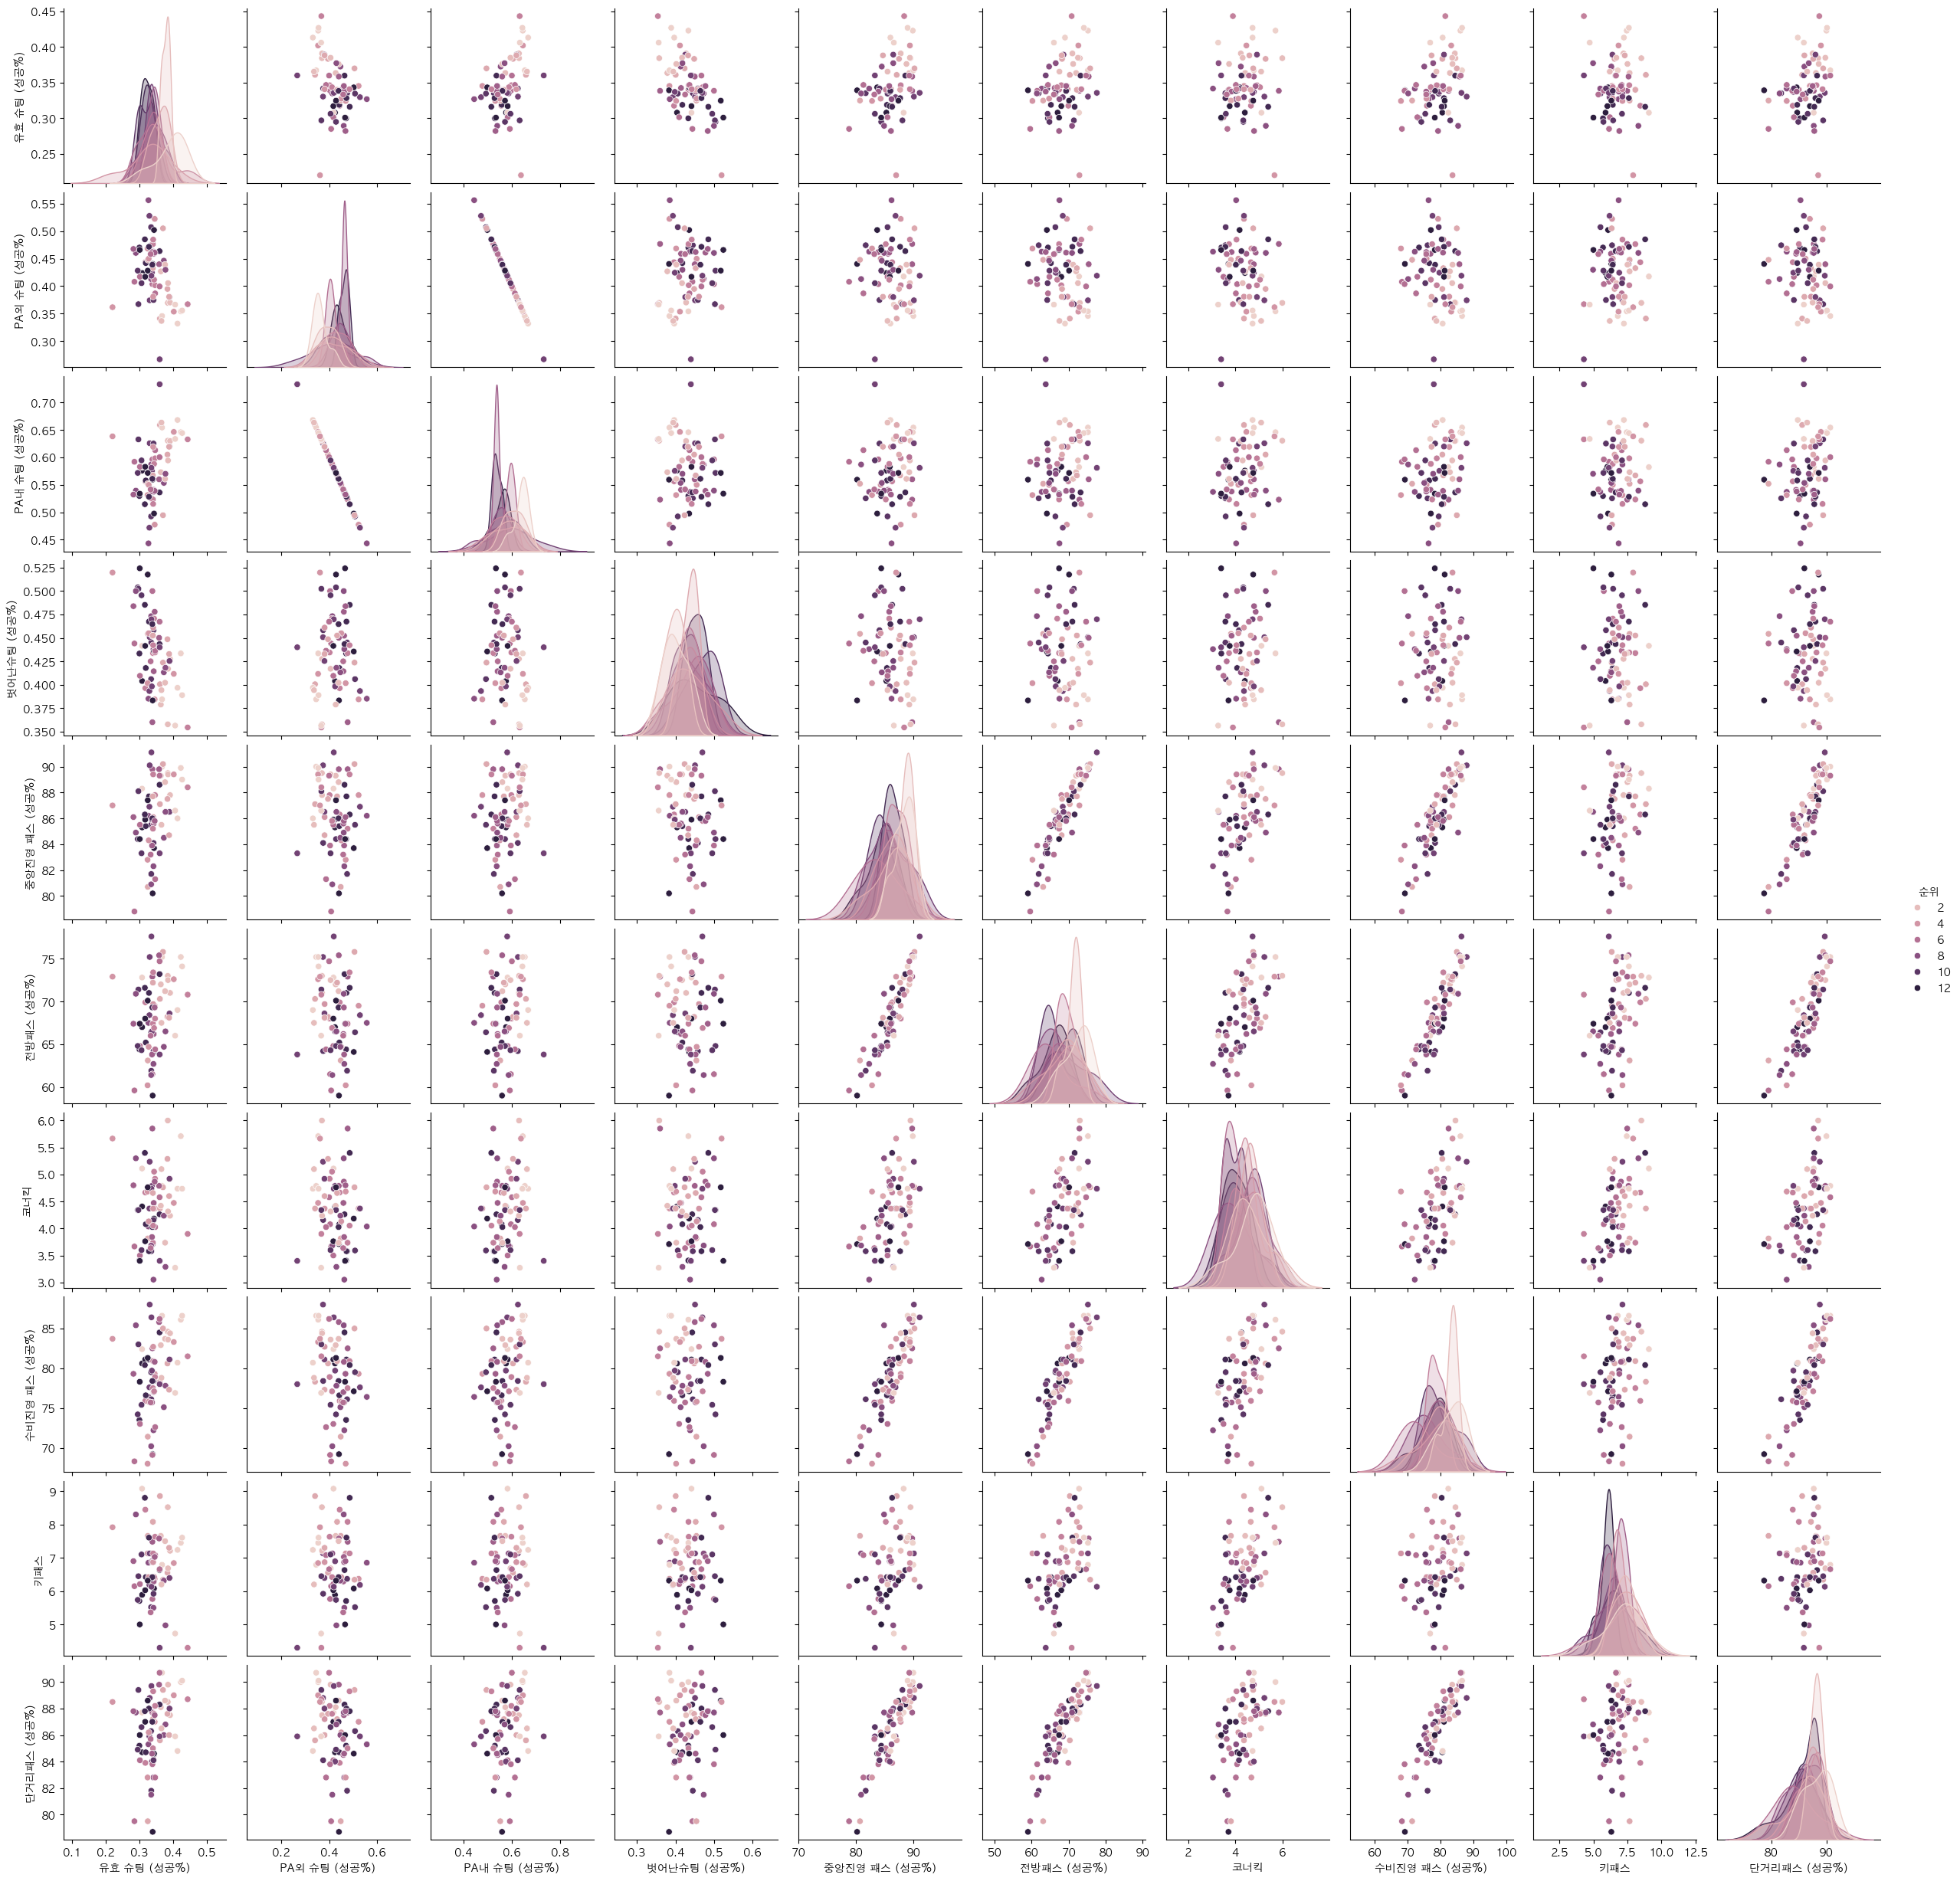

In [1964]:
ddf = data_df[['유효 슈팅 (성공%)','PA외 슈팅 (성공%)','PA내 슈팅 (성공%)','벗어난슈팅 (성공%)','중앙진영 패스 (성공%)',
               '전방패스 (성공%)','코너킥','수비진영 패스 (성공%)','키패스','단거리패스 (성공%)','순위']]

sns.pairplot(ddf, hue='순위')
plt.show()

## SCATTER PLOT
* 순위와 각각의 변수들의 관계를 살펴봄

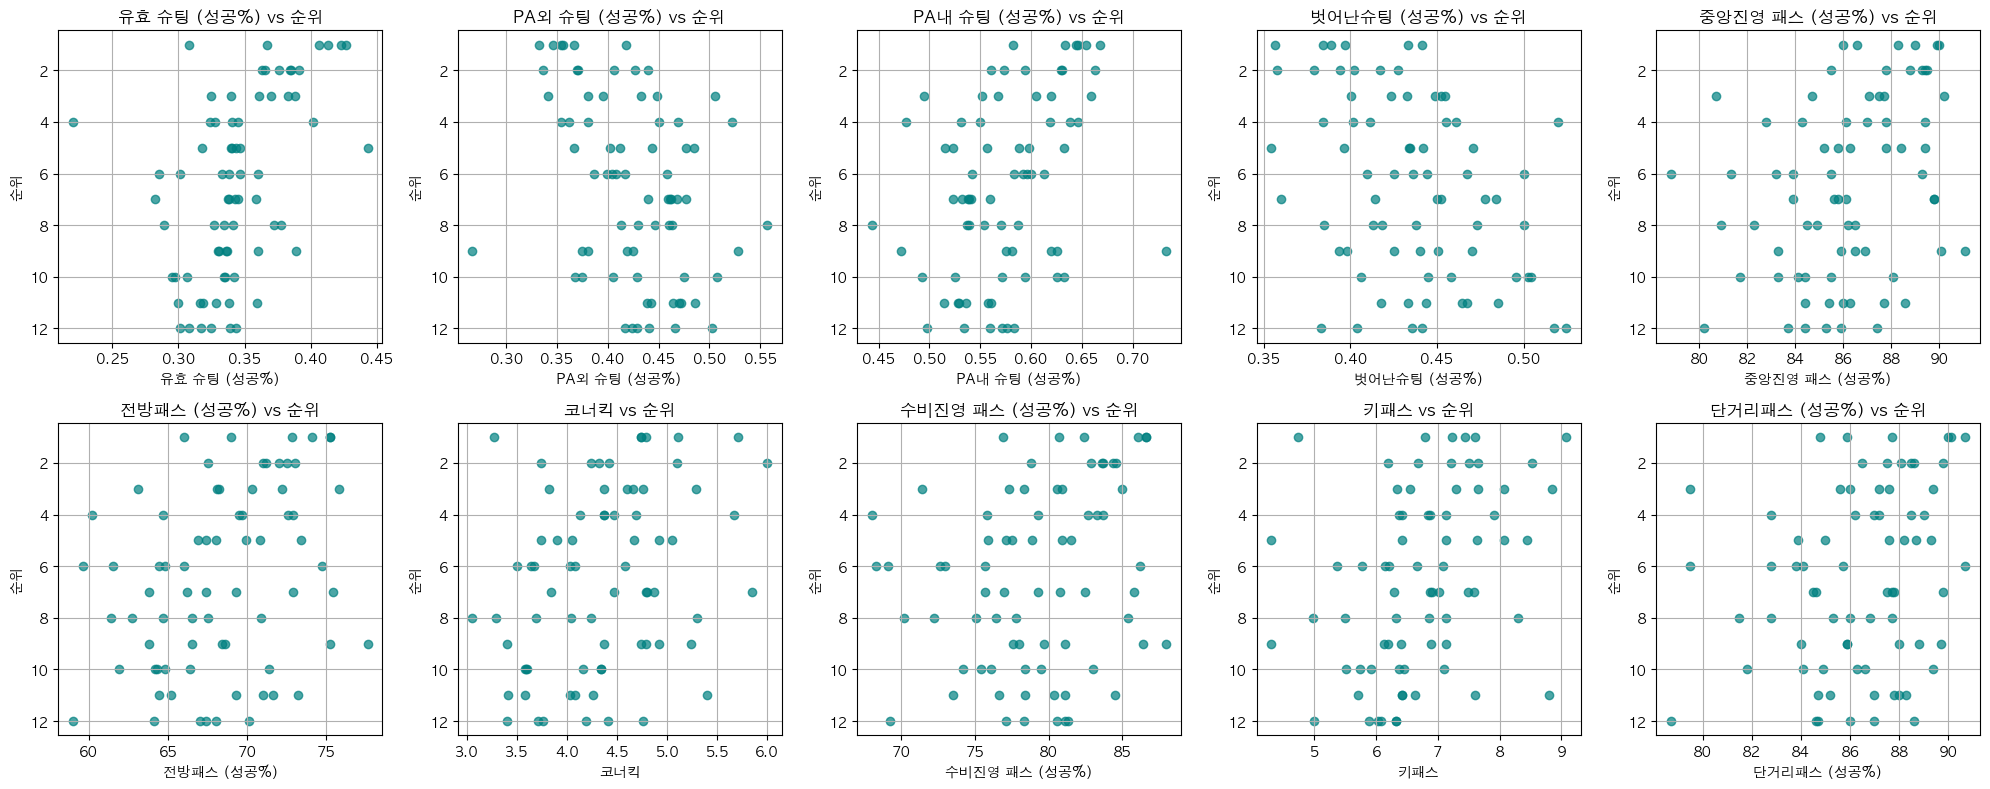

In [1966]:
features = ['유효 슈팅 (성공%)','PA외 슈팅 (성공%)','PA내 슈팅 (성공%)','벗어난슈팅 (성공%)','중앙진영 패스 (성공%)',
            '전방패스 (성공%)','코너킥','수비진영 패스 (성공%)','키패스','단거리패스 (성공%)']

# 서브플롯 설정 (5행 2열)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()  # 2D 배열을 1D로

# 산점도 생성
for i, feature in enumerate(features):
    ax = axes[i]
    ax.scatter(ddf[feature], ddf['순위'], alpha=0.7, color='teal')
    ax.set_title(f'{feature} vs 순위')
    ax.set_xlabel(feature)
    ax.set_ylabel('순위')
    ax.invert_yaxis()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [1967]:
# 유의미한 결과가 나오지 않아서 상위팀(1,2,3)과 하위팀(10,11,12)로 나눠서 살펴보기로 생각
# 상위팀/하위팀 라벨링
ddf = ddf.copy() # added to avoid warning message
ddf['팀분류'] = ddf['순위'].apply(lambda x: '상위팀' if x in [1, 2, 3] else ('하위팀' if x in [10, 11, 12] else '기타'))

In [1968]:
ddf.head()

,유효 슈팅 (성공%),PA외 슈팅 (성공%),PA내 슈팅 (성공%),벗어난슈팅 (성공%),중앙진영 패스 (성공%),전방패스 (성공%),코너킥,수비진영 패스 (성공%),키패스,단거리패스 (성공%),순위,팀분류
0,0.338462,0.476923,0.523077,0.360000,89.8,72.9,5.851852,82.5,7.481481,87.7,7,기타
1,0.285199,0.407942,0.592058,0.444043,78.8,59.6,3.666667,68.3,6.148148,79.5,6,기타
2,0.317585,0.443570,0.556430,0.396325,86.3,69.9,4.666667,75.9,8.444444,83.9,5,기타
3,0.308000,0.424000,0.576000,0.404000,85.3,67.0,4.407407,80.6,5.888889,84.7,12,하위팀
4,0.345345,0.522523,0.477477,0.384384,87.8,69.5,4.370370,79.3,6.370370,87.0,4,기타


## BOX PLOT

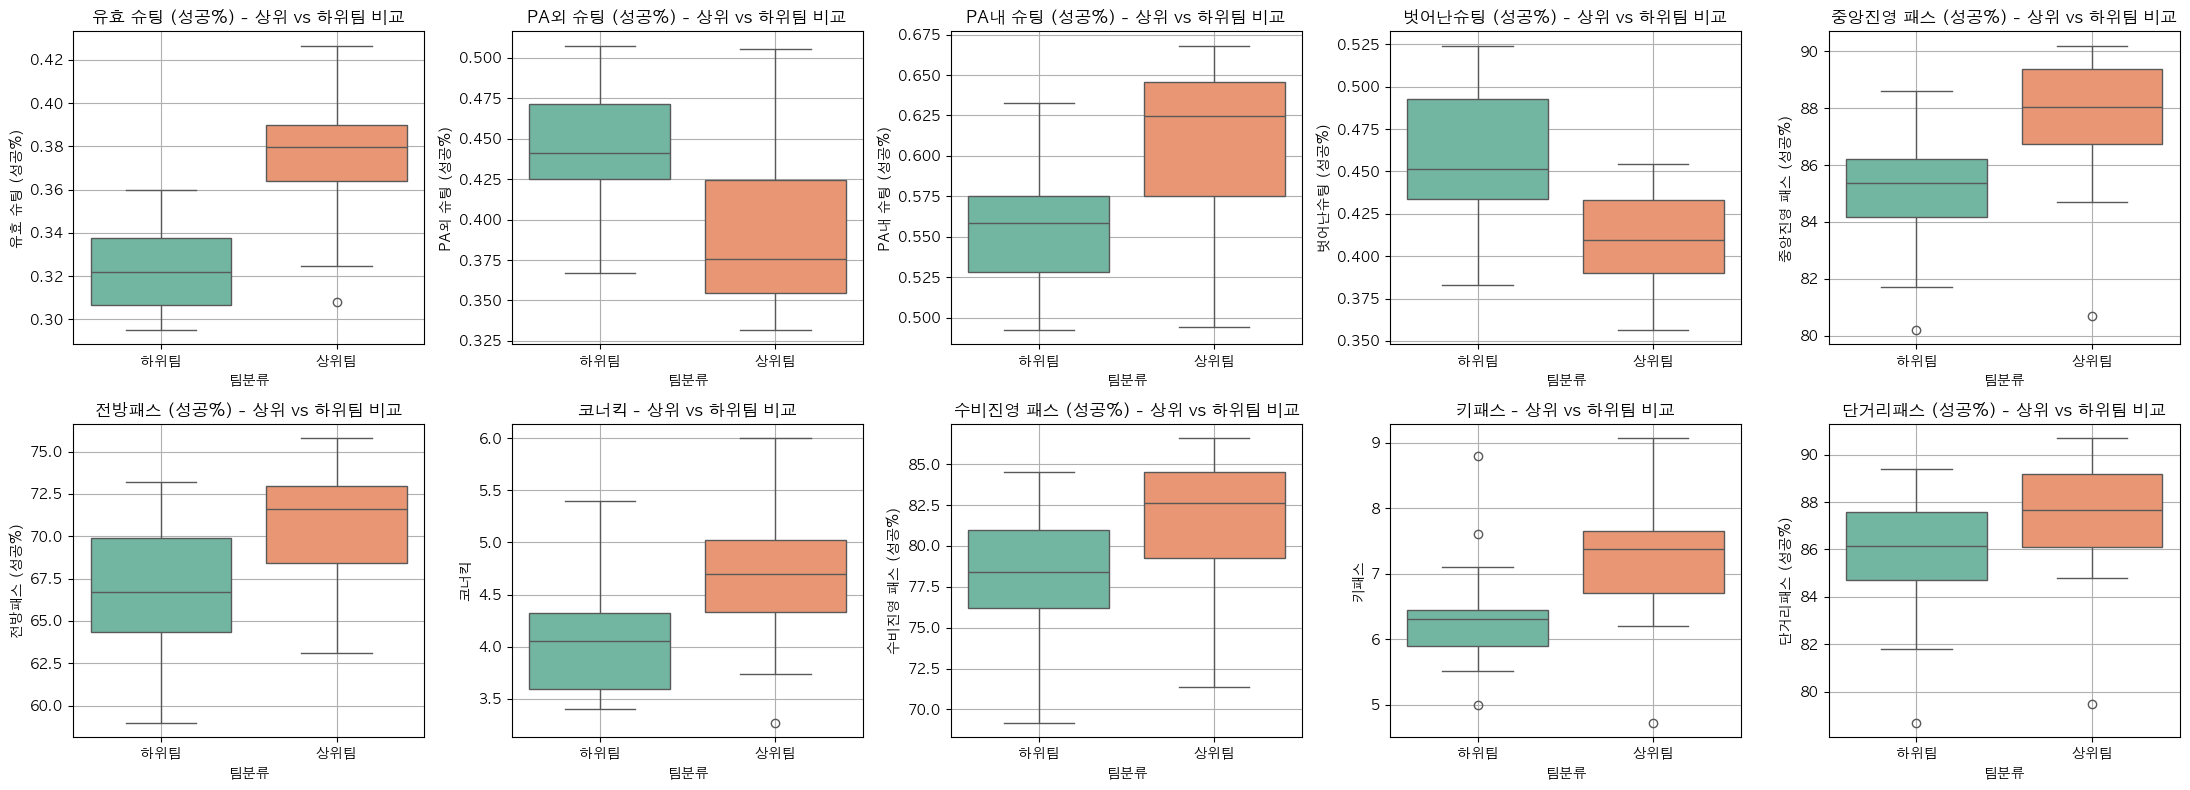

In [1970]:
# 5행 2열
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(22, 8))
axes = axes.flatten()

# 시각화
for i, feature in enumerate(features):
    ax = axes[i]
    sns.boxplot(data=ddf[ddf['팀분류'].isin(['상위팀', '하위팀'])], x='팀분류', y=feature, hue='팀분류', ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{feature} - 상위 vs 하위팀 비교')
    ax.grid(True)

plt.tight_layout()
plt.show()

# 랜덤포레스트 회귀 모델 훈련

In [1972]:
# 2020 ~ 2024년 데이터로 훈련
train_df = data_df[data_df["년도"] < 2025].copy()

In [1973]:
x = train_df.drop(['순위','년도','경기','구단','승점'], axis=1)
y = train_df['순위']

In [1974]:
x.shape, y.shape

((60, 62), (60,))

In [1975]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 22)

In [1976]:
rr = RandomForestRegressor()
rr.fit(x_train, y_train)

RandomForestRegressor()

## 모델 평가

In [1978]:
print(rr.score(x_train, y_train))
print(rr.score(x_test, y_test))

0.9746143353192733
0.842621609862219


# 올해 2025년 k리그 축구 팀 순위는?

In [1980]:
# 2025년 데이터로 테스트 및 예측
predict_df = data_df[data_df["년도"] == 2025].copy()

In [1981]:
data_df.shape

(72, 67)

In [1982]:
x_2025 = predict_df.drop(['승점','순위','년도','경기','구단'], axis=1)

In [1983]:
predict_2025 = predict_df['순위']

In [1984]:
# 2025년 순위 예측
pred = rr.predict(x_2025)
pred

array([ 6.67,  3.28,  2.52, 10.85,  2.2 ,  7.53, 10.64,  5.29,  3.98,
        1.98,  8.24,  4.11])

In [1985]:
# 모델이 예측한 순위를 구단과 맞추기
ranking_2025 = predict_df[['구단']].copy()
ranking_2025["모델 예측 순위"] = pred
ranking_2025 = ranking_2025.sort_values(by="모델 예측 순위").reset_index(drop=True)

In [1986]:
ranking_2025

,구단,모델 예측 순위
0,전북,1.98
1,대전,2.20
2,김천,2.52
3,광주,3.28
4,울산,3.98
5,포항,4.11
6,안양,5.29
7,강원,6.67
8,서울,7.53
9,제주,8.24


In [1987]:
# 예측 순위 열에 .rank()를 적용하여 1등부터 12등까지 나오도록 대체
ranking_2025['예측 순위'] = ranking_2025['모델 예측 순위'].rank().astype(int)

In [1988]:
ranking_2025

,구단,모델 예측 순위,예측 순위
0,전북,1.98,1
1,대전,2.20,2
2,김천,2.52,3
3,광주,3.28,4
4,울산,3.98,5
5,포항,4.11,6
6,안양,5.29,7
7,강원,6.67,8
8,서울,7.53,9
9,제주,8.24,10


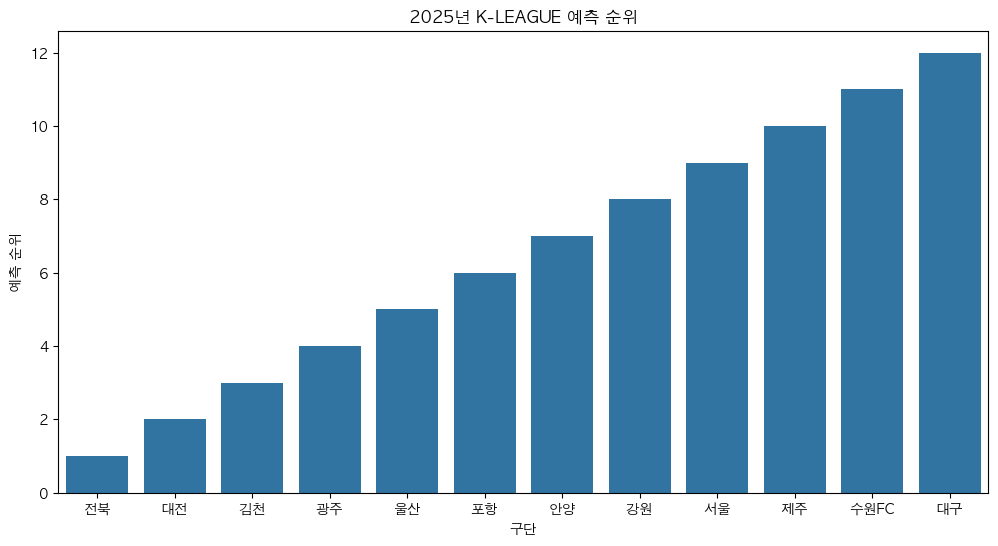

In [1989]:
plt.figure(figsize = (12, 6))
sns.barplot(x=ranking_2025['구단'], y=ranking_2025['예측 순위'])

plt.xlabel('구단')
plt.ylabel('예측 순위')
plt.title('2025년 K-LEAGUE 예측 순위')
plt.show()

In [1990]:
# 평가
mae = mean_absolute_error(predict_2025, pred)
mae

1.0925